# <center>Principal component analysis<center>

1. Eigenvectors
2. SVD (Singular Value Decomposition)

Importing libraries

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

---

Importing data

In [2]:
path = os.path.abspath('../data/iris/iris.data')
df = pd.read_csv(path, header=None)

---

Checking data

In [3]:
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
df.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class']

df

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


---

Visualizing data

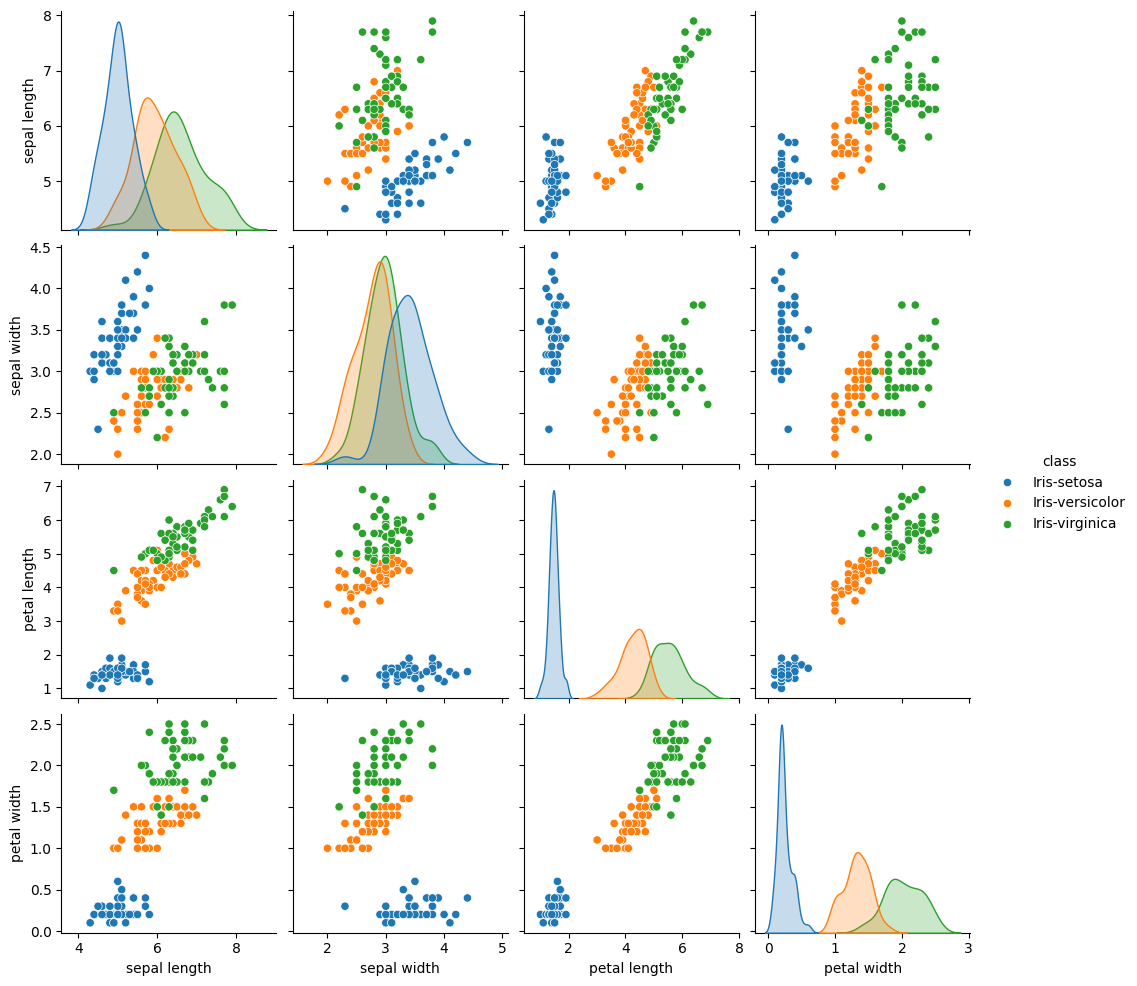

In [5]:
sns.pairplot(df, hue='class')

---

### **Eigenvectors**

[0.92461621 0.05301557 0.01718514 0.00518309]


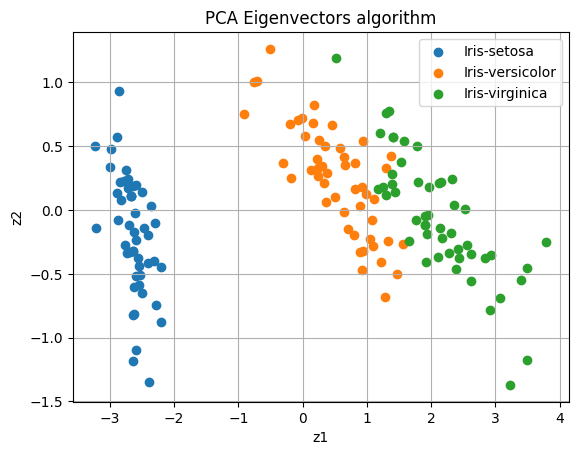

In [6]:
from pca_eigenvectors import PCA_eigenvectors
X = df[['sepal length', 'sepal width', 'petal length', 'petal width']].to_numpy()
y = df['class'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
})
labels = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

eigenvectors = PCA_eigenvectors()

X_pca = eigenvectors.fit_transform(X, 2)
print(eigenvectors.explained_ratio)

fig, ax = plt.subplots()
for i in range(len(y.unique())):
    X_mask = X_pca[y == i]
    ax.scatter(x=X_mask[:, 0], y=X_mask[:, 1], label=labels[i])

ax.grid()
ax.set_title('PCA Eigenvectors algorithm')
ax.set_xlabel('z1')
ax.set_ylabel('z2')
ax.legend()

---

### **Singular Value Decomposition**

[0.92461621 0.05301557 0.01718514 0.00518309]


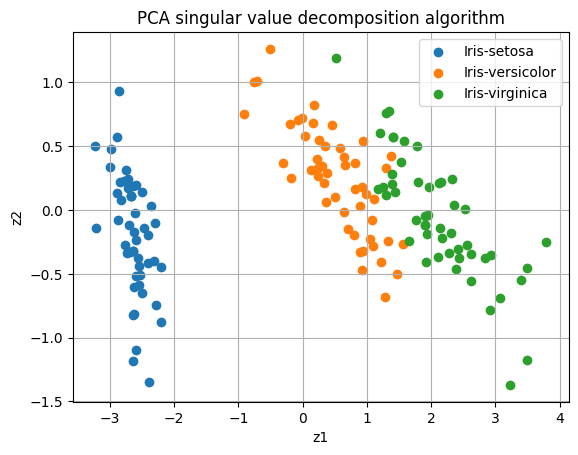

In [7]:
from pca_svd import PCA_SVD
X = df[['sepal length', 'sepal width', 'petal length', 'petal width']].to_numpy()
y = df['class'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
})
labels = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

svd = PCA_SVD()

X_svd = svd.fit_transform(X, 2)
print(svd.explained_ratio)

fig, ax = plt.subplots()
for i in range(len(y.unique())):
    X_mask = X_svd[y == i]
    ax.scatter(x=X_mask[:, 0], y=X_mask[:, 1], label=labels[i])

ax.grid()
ax.set_title('PCA singular value decomposition algorithm')
ax.set_xlabel('z1')
ax.set_ylabel('z2')
ax.legend()

---